In [1]:
pip install textblob wordcloud

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --- ------------------------------------ 61.4/625.0 kB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 491.5/625.0 kB 6.2 MB/s eta 0:00:01
   ---------------------------------------  614.4/625.0 kB 4.3 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---------------------- ----------------- 174.1/306.1 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB 5.3 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.6 MB 5.4 MB/s eta 0:00:01
   ---------------------- ----------------- 0.9/1.6 MB 5.4 MB/s eta 0:00:01
  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
df = pd.read_csv('student_feedback.csv', index_col=0)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (1001, 9)
Columns: ['Student ID', 'Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance']


,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9


In [4]:
cols = ['Well versed with the subject',
        'Explains concepts in an understandable way',
        'Use of presentations',
        'Degree of difficulty of assignments',
        'Solves doubts willingly',
        'Structuring of the course',
        'Provides support for students going above and beyond',
        'Course recommendation based on relevance']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.dropna(subset=cols, inplace=True)

print("✅ Data cleaned!")
print("Final shape:", df.shape)
print("Missing values:", df[cols].isnull().sum().sum())

✅ Data cleaned!
Final shape: (1001, 9)
Missing values: 0


In [9]:
short_names = ['Subject Knowledge',
               'Concept Clarity',
               'Presentation Use',
               'Assignment Difficulty',
               'Doubt Solving',
               'Course Structure',
               'Extra Support',
               'Course Relevance']

df['avg_score'] = df[cols].mean(axis=1)

print("Overall average score:", round(df['avg_score'].mean(), 2))
print("\nAverage Rating per category:")
for col, short in zip(cols, short_names):
    print(f"  {short}: {round(df[col].mean(), 2)}")

Overall average score: 5.92

Average Rating per category:
  Subject Knowledge: 7.5
  Concept Clarity: 6.08
  Presentation Use: 5.94
  Assignment Difficulty: 5.43
  Doubt Solving: 5.47
  Course Structure: 5.64
  Extra Support: 5.66
  Course Relevance: 5.6


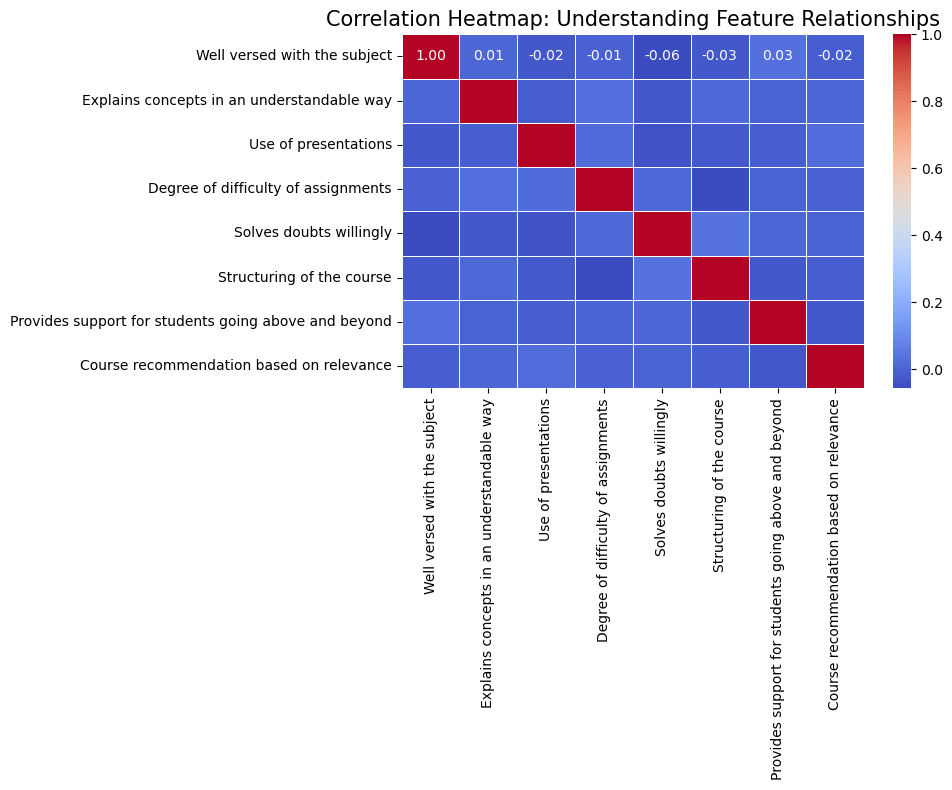

In [24]:
# Create the correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Understanding Feature Relationships', fontsize=15)
plt.tight_layout()
plt.show()

In [21]:
# Select only the rating columns (skip ID and index)
rating_cols = ['Well versed with the subject', 'Explains concepts in an understandable way', 
               'Use of presentations', 'Degree of difficulty of assignments', 
               'Solves doubts willingly', 'Structuring of the course', 
               'Provides support for students going above and beyond', 
               'Course recommendation based on relevance']

# Create a new column called 'Average_Score'
df['Overall_Satisfaction'] = df[rating_cols].mean(axis=1)

# Look at the first few rows to see the new column
df[['Student ID', 'Overall_Satisfaction']].head()

,Student ID,Overall_Satisfaction
0,340,5.000
1,253,4.875
2,680,4.375
3,806,5.875
4,632,7.500


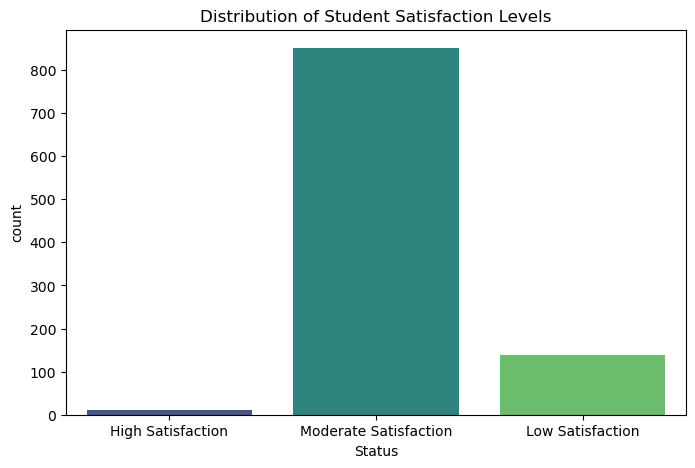

In [12]:
# Define a function to categorize the score
def categorize_satisfaction(score):
    if score >= 8:
        return 'High Satisfaction'
    elif score >= 5:
        return 'Moderate Satisfaction'
    else:
        return 'Low Satisfaction'

# Apply the function
df['Status'] = df['Overall_Satisfaction'].apply(categorize_satisfaction)

# Visualize the groups
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, palette='viridis', order=['High Satisfaction', 'Moderate Satisfaction', 'Low Satisfaction'])
plt.title('Distribution of Student Satisfaction Levels')
plt.show()

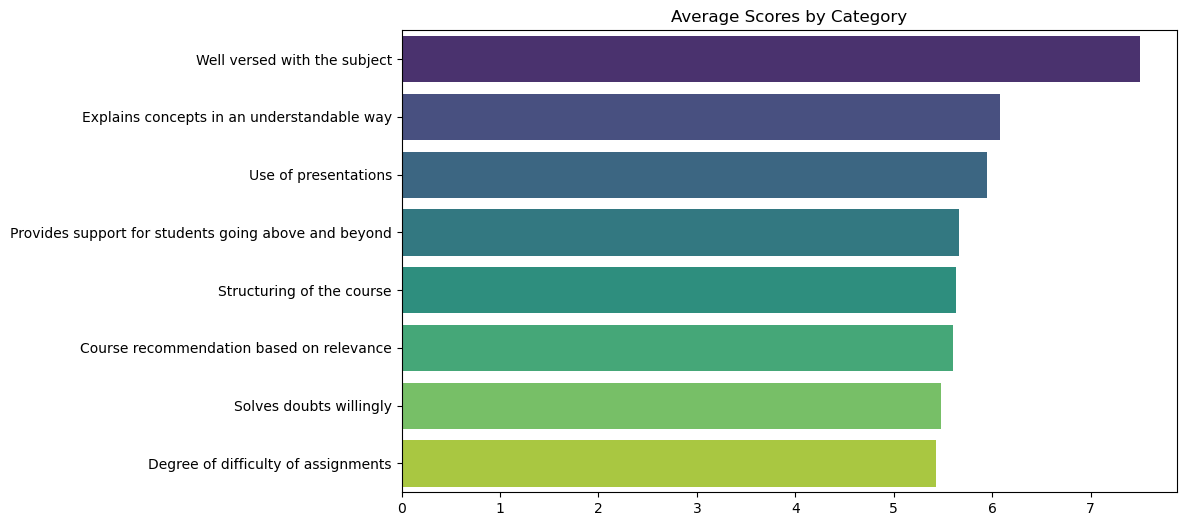

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_feedback.csv')
df_numeric = df.drop(columns=['Student ID', 'Unnamed: 0'], errors='ignore')
averages = df_numeric.mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=averages.values, y=averages.index, palette='viridis')
plt.title('Average Scores by Category')
plt.show()